|dec| < 1.27
ra < 60 or ra > 300

In [120]:
import glob
import pandas as pd
import numpy as np
import os
sub = 10
band = 'w1'
table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,sub+0.1,band))

In [1]:
import pandas as pd
import glob
import os
import time

def one_turn_concat(table_list):
    start = time.time()
    result_table_list = []
    while len(table_list) > 1:
        sub_table1 = table_list.pop()
        sub_table2 = table_list.pop()
        result_table_list.append(pd.concat([sub_table1,sub_table2]))
    if len(table_list) == 1:
        result_table_list.append(table_list.pop())
    result_table_list.reverse()
    return result_table_list

In [ ]:
import glob
import pandas as pd
import numpy as np
import os
sub_table_list = []
for sub in np.arange(7.0,19,0.1):
    print(sub)
    band = 'w2'
    if os.path.isfile('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,sub+0.1,band)):
        table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,sub+0.1,band))
        table = table[abs(table['dec'])<1.27]
        table1 = table[table['ra']<60]
        table2 = table[table['ra']>300]
        sub_table_list.append(pd.concat([table1, table2]))
while(len(sub_table_list))>1:
    sub_table_list = one_turn_concat(sub_table_list)
sub_table_list[0].to_csv('/data/project_unTimely_light_curve/results/%s_paras_in_stripe82.csv'%band,index=False)



In [24]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg
import pandas as pd

from sklearn import mixture

dpgmm = mixture.BayesianGaussianMixture(
        n_components=100,
        covariance_type="full",
        weight_concentration_prior=0.1,
        weight_concentration_prior_type="dirichlet_process",
        mean_precision_prior=1e-2,
        covariance_prior=1e0 * np.eye(13),
        init_params="random_from_data",
        max_iter=100,
        random_state=3,
        degrees_of_freedom_prior=15
    )

band = 'w1'

# table = pd.read_csv('/data/project_unTimely_light_curve/results/%s_paras_in_stripe82.csv'%band)
sub = 8.1
table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,sub+0.1,band))
print(len(table))
table = table[table['corelation']>0.6]
print(len(table))
table = table[['ra','dec','Mean_1','long_name_1','id_in_matched',
   'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
   'L1_acr', 'Stetson_J', 'Stetson_K', 'yita', 'id_w1', 'id_w2']]
table.replace([np.inf, -np.inf], np.nan, inplace=True)
table.dropna(inplace=True)
print(len(table))
X = np.array(table[['Mean_1',
   'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
   'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
dpgmm = dpgmm.fit(X)
Y = dpgmm.predict(X)


123481
55913
55913


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [27]:
from collections import Counter
print(len(Counter(Y)))
Counter(Y)

28


Counter({10: 26545,
         1: 10525,
         57: 24,
         46: 5562,
         20: 2659,
         2: 3926,
         40: 96,
         88: 373,
         70: 1307,
         76: 629,
         79: 255,
         37: 858,
         26: 244,
         21: 357,
         18: 481,
         62: 17,
         61: 340,
         41: 893,
         58: 72,
         14: 66,
         60: 126,
         5: 28,
         90: 144,
         29: 245,
         24: 137,
         36: 2,
         72: 1,
         82: 1})

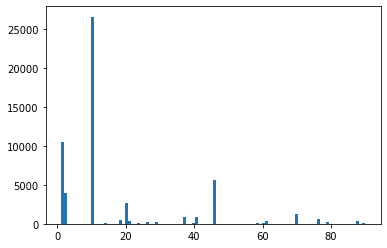

In [28]:
plt.hist(Y,bins = 100)
plt.show()

In [29]:
print(len(dpgmm.means_))
print(dpgmm.weights_)

100
[1.78845765e-05 1.90600210e-01 6.95871074e-02 1.78834292e-05
 1.78829969e-05 4.96611913e-04 1.78821320e-05 1.78816995e-05
 1.78812669e-05 1.78808344e-05 4.70325739e-01 1.78792128e-05
 1.78780239e-05 1.78768350e-05 1.18992921e-03 1.78744523e-05
 1.78732585e-05 1.78720647e-05 8.82726259e-03 1.78696368e-05
 4.66011524e-02 6.45457537e-03 1.78653456e-05 1.78637937e-05
 2.58959163e-03 1.78606707e-05 4.44402674e-03 1.78574936e-05
 1.78558878e-05 4.52492342e-03 1.78526392e-05 1.78509965e-05
 1.78493539e-05 1.78477115e-05 1.78460693e-05 1.78444272e-05
 5.34812345e-05 1.60825734e-02 1.78393528e-05 1.78375627e-05
 1.75487198e-03 1.66445661e-02 1.78319695e-05 1.78299739e-05
 1.78279785e-05 1.78259834e-05 9.93215809e-02 1.78186905e-05
 1.78133942e-05 1.78080994e-05 1.78028062e-05 1.77975146e-05
 1.77922246e-05 1.77869361e-05 1.77816492e-05 1.77763639e-05
 1.77710801e-05 4.44106360e-04 1.28681779e-03 1.77550462e-05
 2.23477271e-03 6.77547639e-03 3.19072887e-04 1.77310883e-05
 1.77246316e-05 1.77

In [30]:
counts = np.bincount(Y)
max_cluster = np.argmax(counts)
max_means = dpgmm.means_[max_cluster]
print(max_means)
max_cov = dpgmm.covariances_[max_cluster]
print(max_cov)

[ 0.11700868 -0.34333123 -0.34715864 -0.62459464 -0.59536968 -0.599481
 -0.58760837 -0.37538941 -0.60529913  0.29719265  0.22583345 -0.42573773
 -0.43175254]
[[ 9.59748806e-01 -6.56217496e-03 -7.07290398e-03 -1.67655356e-02
  -1.79095447e-02 -1.70983587e-02 -2.96939964e-02 -4.07384505e-03
  -1.94661177e-02  3.12154485e-02 -4.23010820e-03 -4.24433960e-02
  -3.21704666e-02]
 [-6.56217496e-03  1.19271437e-03  1.02784168e-03  3.67925420e-03
   1.98454949e-03  1.87595759e-03  3.76302085e-03  7.87745534e-04
   4.53359009e-03  3.30047045e-03  1.44883864e-03 -3.84338720e-03
  -1.91878054e-03]
 [-7.07290398e-03  1.02784168e-03  9.80650539e-04  3.39058026e-03
   1.92646225e-03  1.81992157e-03  3.49845915e-03  7.26831074e-04
   4.09553327e-03  2.42742919e-03  1.13129938e-03 -2.75136870e-03
  -1.16195208e-03]
 [-1.67655356e-02  3.67925420e-03  3.39058026e-03  1.33446268e-02
   8.02682741e-03  7.58007231e-03  1.30012924e-02  2.80395860e-03
   1.55428821e-02  1.12160832e-02  4.19417983e-03 -6.836733

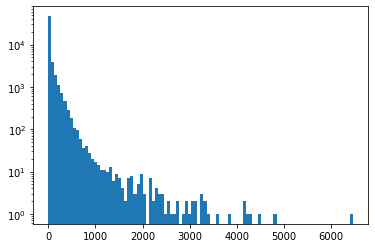

In [31]:
from scipy.spatial.distance import mahalanobis

cov = np.cov(X,rowvar=False)
# VI = np.linalg.inv(cov)
VI = np.linalg.inv(max_cov)
distances = [mahalanobis(x,max_means,VI) for x in X]
distances = np.array(distances)
plt.hist(distances,bins=100,log=True)
plt.show()

In [32]:
result_lists = []
for i in range(100):
    result_lists.append([])
ras = np.array(table['ra'])
decs = np.array(table['dec'])
ids = np.array(table['id_in_matched'])
names = np.array(table['long_name_1'])
id_w1s = np.array(table['id_w1'])
id_w2s = np.array(table['id_w2'])
for (i, label) in enumerate(Y):
    ra = ras[i]
    dec = decs[i]
    index = ids[i]
    name = names[i]
    id_w1 = id_w1s[i]
    id_w2 = id_w2s[i]
    distance = distances[i]

    result_lists[label].append((ra, dec, index, name, id_w1, id_w2, distance))

# for i in range(3):
#     df = pd.DataFrame(result_lists[i])
#     df.to_csv('/data/project_unTimely_light_curve/results/para_tuning/%d_split_%d.csv'%(3,i),
#             index=False,header=['ra','dec','id_in_matched','long_name','id_w1','id_w2'])

In [35]:
max_cluster_list = result_lists[max_cluster]
max_cluster_distances = [x[6]for x in max_cluster_list]
distance_95_percent = np.percentile(np.array(max_cluster_distances),95)
print(distance_95_percent)
distance_99_percent = np.percentile(np.array(max_cluster_distances),99)
print(distance_99_percent)
distance_997_percent = np.percentile(np.array(max_cluster_distances),99.7)
print(distance_997_percent)

4.569379162458825
5.301006177390612
5.823026722261234


In [50]:
from scipy.stats import chi2
num_samples = 1000000

inv_cov = np.linalg.inv(max_cov)
r_mc_list = []
for i in range(1,20):
    samples = np.random.multivariate_normal(max_means, max_cov, size = num_samples)
    # mahalanobis_dist = np.array([mahalanobis(x,max_means,cov) for x in samples])

    diff = samples - max_means
    mahalanobis_sq = np.sum((diff @ inv_cov) * diff,axis=1)
    mahalanobis_dist = np.sqrt(mahalanobis_sq)

    r_mc = np.percentile(mahalanobis_dist, 99.7)
    r_mc_list.append(r_mc)

r_mc = np.mean(r_mc_list)

d = len(max_means)
chi2_r_sq = chi2.ppf(0.997, df=d)
r_theory = np.sqrt(chi2_r_sq)

print(r_mc, r_theory)


5.599094634012076 5.598755145827807


In [51]:
variable_list = []
for (i, distance) in enumerate(distances):
    if distance > r_mc:
        ra = ras[i]
        dec = decs[i]
        index = ids[i]
        name = names[i]
        id_w1 = id_w1s[i]
        id_w2 = id_w2s[i]
        distance = distances[i]

        variable_list.append((ra, dec, index, name, id_w1, id_w2, distance))
print(len(variable_list))

26804


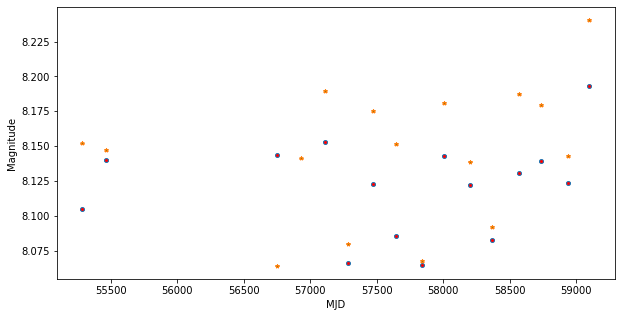

In [38]:
from IPython.display import clear_output
# target_list = result_lists[13]
target_list = variable_list
i=0
while i < len(target_list):
    clear_output(wait=True)
    long_name = target_list[i][3]
    name = long_name[0:3]
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    id_w1 = target_list[i][4]
    id_w2 = target_list[i][5]
    from util import make_single_light_curve
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    plt.figure(figsize=(10,5))
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

    plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
    plt.show()
    user_input = input('Do you want to continue? (y/n)')
    import random
    i+=random.randint(1,20)

    if user_input == 'n':

        break



In [319]:
dpgmm_3divide = mixture.BayesianGaussianMixture(
        n_components=3,
        covariance_type="full",
        weight_concentration_prior=0.1,
        weight_concentration_prior_type="dirichlet_process",
        mean_precision_prior=1e-2,
        covariance_prior=1e0 * np.eye(13),
        init_params="random_from_data",
        max_iter=100,
        random_state=3,
        degrees_of_freedom_prior=15
    )
dpgmm_3divide = dpgmm_3divide.fit(X)
Y_3divide = dpgmm_3divide.predict(X)

In [320]:
Counter(Y_3divide)

Counter({1: 41683, 2: 37864, 0: 1890})

(array([ 1890.,     0.,     0.,     0.,     0., 41683.,     0.,     0.,
            0., 37864.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

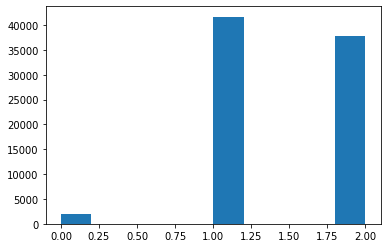

In [321]:
plt.hist(Y_3divide)

In [322]:
result_lists_3divide = []
for i in range(3):
    result_lists_3divide.append([])
for (i, label) in enumerate(Y_3divide):
    ra = ras[i]
    dec = decs[i]
    index = ids[i]
    name = names[i]
    id_w1 = id_w1s[i]
    id_w2 = id_w2s[i]
    distance = distances[i]

    result_lists_3divide[label].append((ra, dec, index, name, id_w1, id_w2, distance))

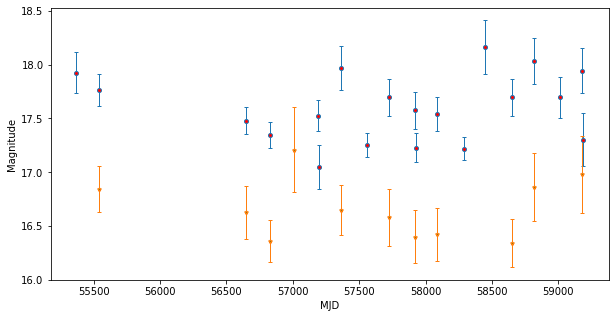

In [323]:
target_list = result_lists_3divide[0]
i=0
while i < len(target_list):
    clear_output(wait=True)
    long_name = target_list[i][3]
    name = long_name[0:3]
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    id_w1 = target_list[i][4]
    id_w2 = target_list[i][5]
    from util import make_single_light_curve
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    plt.figure(figsize=(10,5))
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

    plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
    plt.show()
    user_input = input('Do you want to continue? (y/n)')
    import random
    i+=random.randint(1,5)

    if user_input == 'n':
        
        break

In [73]:
X_var = []
id_list = []
var_table = []

for i,y in enumerate(Y):
    if y == 0:
        X_var.append(X[i])
        id_list.append(i)
        var_table.append(table.iloc[i])

X_var = np.array(X_var)
print(len(X_var))
print(X_var.shape)
print(X_var[0])

2778
(2778, 13)
[ 1.32016213 -0.06777447 -0.06535001  2.11259424  1.6970486   1.00970633
 -0.52220327 -1.06868182 -0.26560514 -1.31109318 -0.07897222  0.89916637
  1.37485811]


(array([ 699.,    0.,  604.,    0.,    0.,  189.,    0.,   84.,    0.,
        1202.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

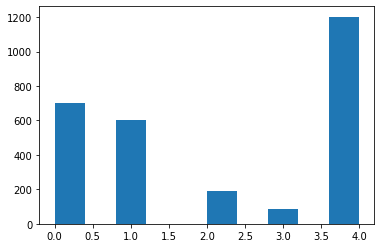

In [94]:
dpgmm_var = mixture.BayesianGaussianMixture(
    n_components=5,
    covariance_type="full",
    weight_concentration_prior=1e-2,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)
dpgmm_var.fit(X_var)

Y_var = dpgmm_var.predict(X_var)

plt.hist(Y_var)

In [95]:
var_table = pd.DataFrame(var_table)

result_lists_var = []
for i in range(5):
    result_lists_var.append([])
ras = np.array(var_table['ra'])
decs = np.array(var_table['dec'])
ids = np.array(var_table['id_in_matched'])
names = np.array(var_table['long_name_1'])
id_w1s = np.array(var_table['id_w1'])
id_w2s = np.array(var_table['id_w2'])
for (i, label) in enumerate(Y_var):
    ra = ras[i]
    dec = decs[i]
    index = ids[i]
    name = names[i]
    id_w1 = id_w1s[i]
    id_w2 = id_w2s[i]

    result_lists_var[label].append((ra, dec, index, name, id_w1, id_w2))

In [116]:
band = 'w1'
sub = 12.5
upper = 12.6
source_table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,upper,band)) 
print(len(source_table))

2086937


In [117]:
print(source_table.columns)

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'long_name_1',
       'id_in_matched', 'ra', 'dec', 'Mean_1', 'chi_squre', 'rcs', 'w_sigma',
       'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv', 'L1_acr', 'Stetson_J',
       'Stetson_K', 'yita', 'Mean_2', 'long_name_2', 'ra1', 'dec1', 'ra2',
       'dec2', 'id_w1', 'id_w2', 'corelation', 'Separation'],
      dtype='object')


In [118]:
df = source_table[['ra','dec','id_in_matched','long_name_1','id_w1','id_w2', 'corelation']]


0.2681854414645616


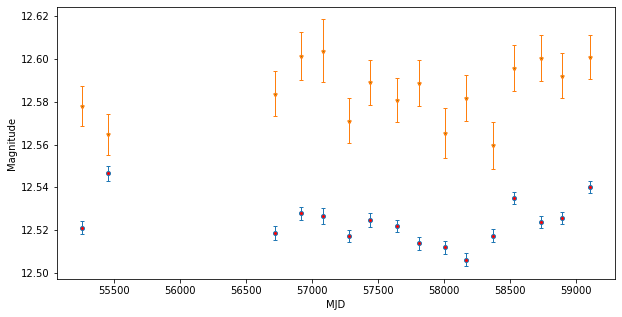

In [119]:
from IPython.display import clear_output
# target_list = result_lists_var[1]
target_list = np.array(df)
i=0
while i < len(target_list):
    clear_output(wait=True)
    long_name = target_list[i][3]
    name = long_name[0:3]
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    id_w1 = target_list[i][4]
    id_w2 = target_list[i][5]
    from util import make_single_light_curve
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    
    print(target_list[i][6])  #临时加的，用于查看全部源，正常使用要去掉
    
    plt.figure(figsize=(10,5))
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

    plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
    plt.show()
    user_input = input('Do you want to continue? (y/n)')
    import random
    i+=random.randint(1,50)

    if user_input == 'n':


        break

In [46]:
import numpy as np
from matplotlib import pyplot as plt    

cof_list = []
for i in range(0,100000):
    t = np.linspace(0,16,16)
    base_signal = 0.00001 * np.sin(2 * np.pi * t/16)
    y1 = base_signal + np.random.normal(0,0.02,len(t))
    y2 = base_signal + 1 + np.random.normal(0,0.05,len(t))

    y2[3]+=0.75
    y2[6]+=0.75

    cof_list.append(np.corrcoef(y1,y2)[0,1])


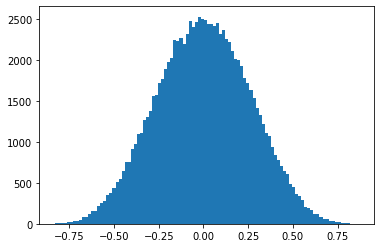

In [47]:
plt.hist(cof_list,bins=100)
plt.show()

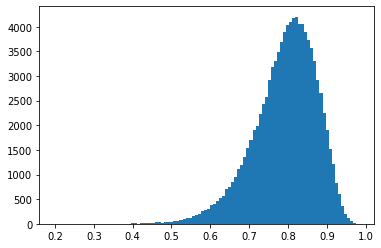

In [48]:
cof_list = []
for i in range(0,100000):
    t = np.linspace(0,16,16)
    base_signal = 1.00001 * np.sin(2 * np.pi * t/16)
    y1 = base_signal + np.random.normal(0,0.2,len(t))
    y2 = base_signal + 1 + np.random.normal(0,0.5,len(t))

    # y2[3]+=0.75

    cof_list.append(np.corrcoef(y1,y2)[0,1])
plt.hist(cof_list,bins=100)
plt.show()

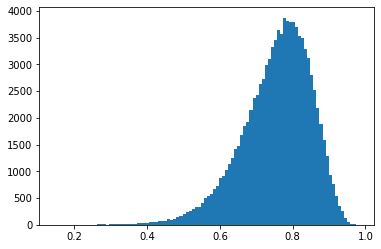

In [49]:
cof_list = []
for i in range(0,100000):
    t = np.linspace(0,16,16)
    base_signal = t*0.125
    y1 = base_signal + np.random.normal(0,0.2,len(t))
    y2 = base_signal + 1 + np.random.normal(0,0.5,len(t))

    # y2[3]+=0.75

    cof_list.append(np.corrcoef(y1,y2)[0,1])
plt.hist(cof_list,bins=100)
plt.show()